# Project: Investigate a Dataset - (no_show_appointments)

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

>This dataset collects information from 100k medical appointments in Brazil and is focused on the question of whether or not patients show up for their appointment. A number of characteristics about the patient are included in each row.
<ul>
<li>ScheduledDay: The day the patient went to make an appointment.</li>
<li>AppointmentDay: The day the patient should go to see the doctor</li>
<li>Neighborhood:indicates the location of the hospital.</li>
<li>Scholarship:indicates whether or not the patient is enrolled in Brasilian welfare program Bolsa Família.</li>
<li>age:patient's age.</li>
<li>Hypertension:Indicates whether the patient's blood pressure is high or not.</li>
<li>Diabetes: It shows whether the patient has diabetes or not.</li>
<li>Alcoholism: It shows whether the patient is an alcoholic or not.</li>
<li>Handcap  :Indicate whether the patient has a disability or not.</li>
<li>no_show  :Indicates whether the patient came to the appointment or not.</li>
</ul>  

#### Be careful about the encoding of the last column: it says ‘No’ if the patient showed up to their appointment, and ‘Yes’ if they did not show


### Question(s) for Analysis

>What are the factors affecting the patient’s attendance or non-attendance?
>>To find out, I'll look for the relationship between the attribute in each column and the patient's attendance at the appointment

In [1]:
# Import the libraries that I will use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
% matplotlib inline

<a id='wrangling'></a>
## Data Wrangling
### General Properties


In [2]:
# Load your data and print out a few lines. Perform operations to inspect data
#   types and look for instances of missing or possibly errant data.
data=pd.read_csv('noshowappointments-kagglev2-may-2016 (2).csv')
data.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
 data.shape

(110527, 14)

In [4]:
data.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [5]:
# Checking the data type of each column as well as missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
PatientId         110527 non-null float64
AppointmentID     110527 non-null int64
Gender            110527 non-null object
ScheduledDay      110527 non-null object
AppointmentDay    110527 non-null object
Age               110527 non-null int64
Neighbourhood     110527 non-null object
Scholarship       110527 non-null int64
Hipertension      110527 non-null int64
Diabetes          110527 non-null int64
Alcoholism        110527 non-null int64
Handcap           110527 non-null int64
SMS_received      110527 non-null int64
No-show           110527 non-null object
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [6]:
# Check for duplicate rows
data.duplicated().sum()

0


### Data Cleaning
<ul>
<li>The data type problem in the column (AppointmentDay) is string and I want it to be datetime type.</li>
<li>this columns (PatientId,AppointmentID,ScheduledDay) i don't need them in my analses so l will drop them</li>
    <li>There is a problem with the age column. The youngest age is negative one,I think it is wrong, so I will drop it.</li>
</ul>

In [9]:
#I need the AppointmentDay column type to be datetime
data['AppointmentDay']=pd.to_datetime(data['AppointmentDay'])


In [11]:
# I will need a day in my analysis so I created a column for it
data['day']=data['AppointmentDay'].dt.day_name()
data['month']=data['AppointmentDay'].dt.month



In [12]:
#I will drop these columns because they will not help me in the analysis because they are attached to the client
data.drop(["PatientId",'AppointmentID','ScheduledDay'],axis=1,inplace=True)


In [17]:
#In the age column there is a value of -1 I think it is wrong so I will drop it

ronge_data_2=data[data['Age'] == -1 ].index
data.drop(ronge_data_2,axis=0,inplace=True)

In [18]:
# I will change the column name No-show to No_show
data.rename(columns={'No-show':'No_show'},inplace=True)

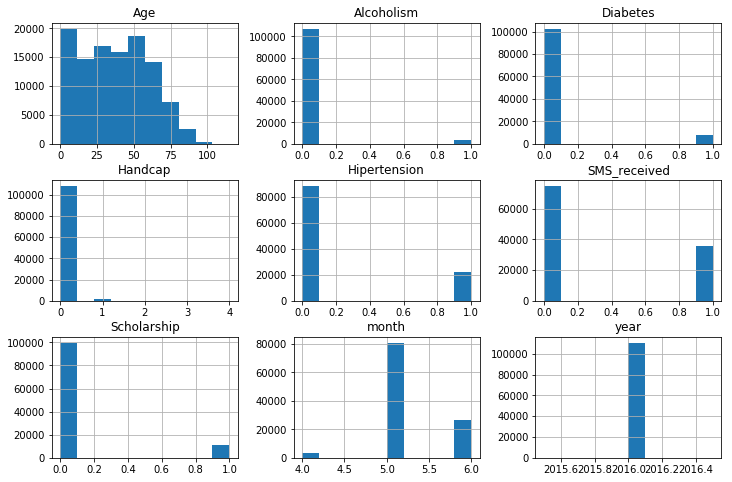

In [19]:
data.hist(figsize=(12,8));

<ul>
    <li>In general, the percentage of people who have any of these diseases is much lower than the people who do not have it</li>
    <li>Almost half of the people received a message</li>
    <li>The most common disease of these diseases is high blood pressure</li>
</ul>

<a id='eda'></a>
## Exploratory Data Analysis


### Research Question 1 :Is there a day when the attendance rate is large?


In [20]:
# I will divide the data into two parts, those who came and those who did not
come=data[data['No_show'] == 'No']
no_come=data[data['No_show']=='Yes']

In [21]:
come_day=come['day'].value_counts()
no_come_day=no_come['day'].value_counts()

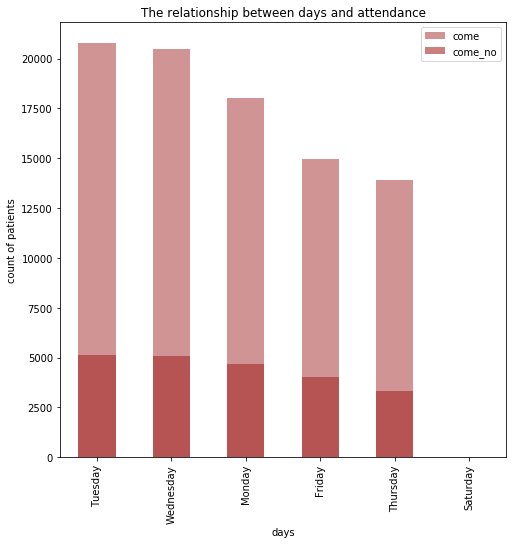

In [16]:
come_day.plot(kind='bar',alpha=0.5,color='brown',figsize=(8,8),label='come');
no_come_day.plot(kind='bar',alpha=0.6,color='brown',figsize=(8,8),label = 'come_no');
plt.title('The relationship between days and attendance');
plt.xlabel('days');
plt.ylabel('count of patients');
plt.legend();

### Research Question 2:Does the patient's gender affect attendance?

In [22]:
come_gender=come['Gender'].value_counts()
no_come_gender=no_come['Gender'].value_counts()

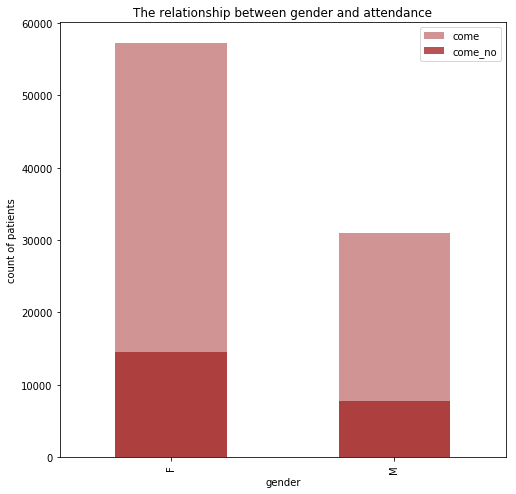

In [23]:
come_gender.plot(kind='bar',alpha=0.5,color='brown',figsize=(8,8),label='come');
no_come_gender.plot(kind='bar',alpha=0.8,color='brown',figsize=(8,8),label = 'come_no',);
plt.title('The relationship between gender and attendance')
plt.xlabel('gender');
plt.ylabel('count of patients');
plt.legend();

#### There is no correlation between gender and presence

### Research Question 3:The relationship between these three variables: gender, days, and attendance?

In [26]:
come_group_day_gender=come.groupby(['day'])['Gender'].value_counts()
no_come_geoup_day_gender=no_come.groupby(['day'])['Gender'].value_counts()

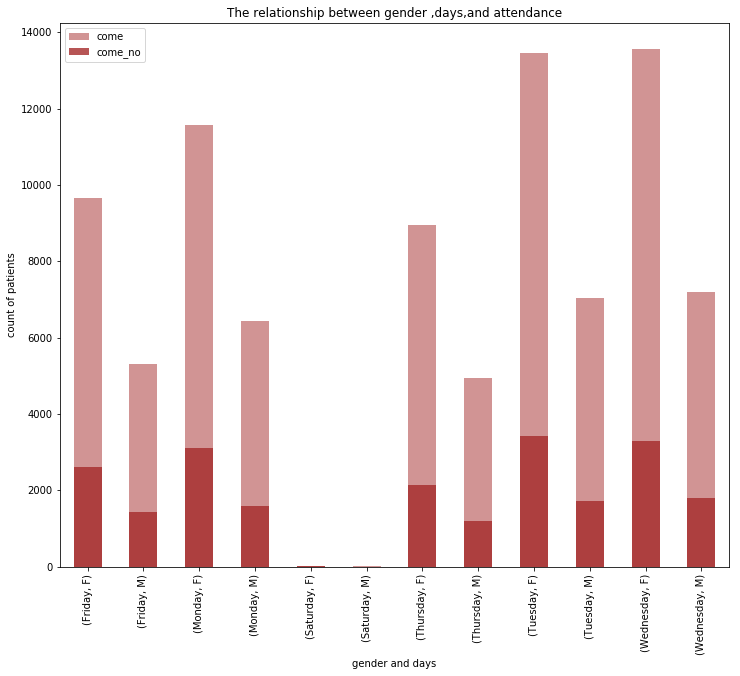

In [27]:
come_group_day_gender.plot(kind='bar',alpha=0.5,color='brown',figsize=(12,10),label='come');
no_come_geoup_day_gender.plot(kind='bar',alpha=0.8,color='brown',figsize=(12,10),label = 'come_no',);
plt.title('The relationship between gender ,days,and attendance')
plt.xlabel('gender and days');
plt.ylabel('count of patients');
plt.legend();

#### There is no correlation between gender, attendance, and days, as there is no specific day the percentage of men who attended is higher than women. This is for example.

### Research Question 4:Is there a particular month in which the attendance rate is high?

In [28]:
come_month=come['month'].value_counts()
no_come_month=no_come['month'].value_counts()

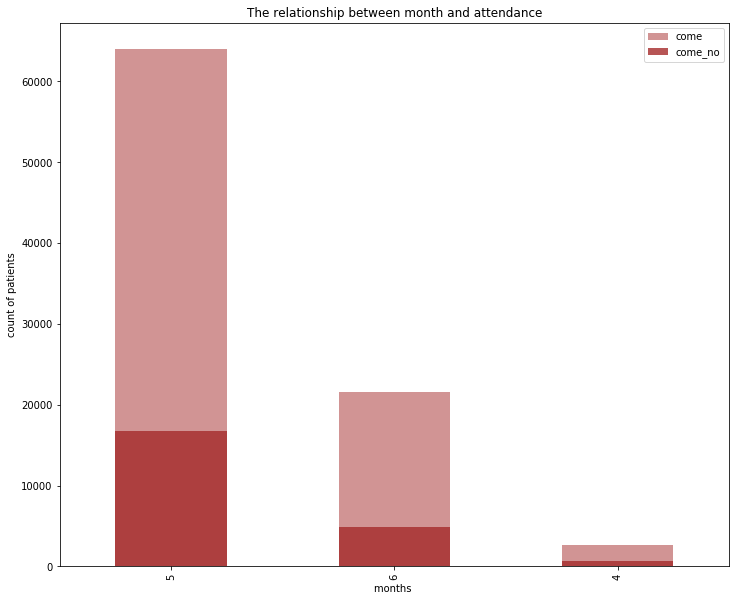

In [29]:
come_month.plot(kind='bar',alpha=0.5,color='brown',figsize=(12,10),label='come');
no_come_month.plot(kind='bar',alpha=0.8,color='brown',figsize=(12,10),label = 'come_no',);
plt.title('The relationship between month and attendance')
plt.xlabel('months ');
plt.ylabel('count of patients');
plt.legend();

### Research Question 5:The relationship between the three variables: gender, month, and attendance

In [30]:
come_group_month_gender=come.groupby(['month'])['Gender'].value_counts()
no_come_group_month_gender=no_come.groupby(['month'])['Gender'].value_counts()

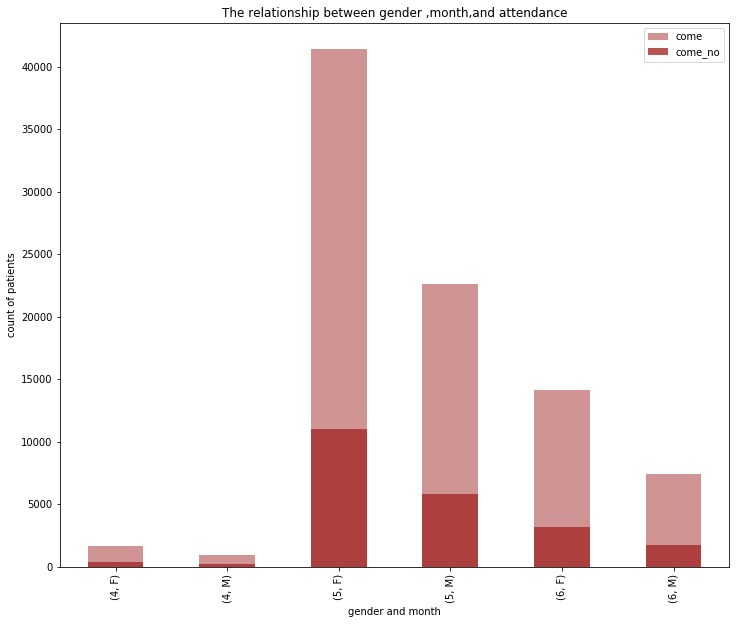

In [31]:
come_group_month_gender.plot(kind='bar',alpha=0.5,color='brown',figsize=(12,10),label='come');
no_come_group_month_gender.plot(kind='bar',alpha=0.8,color='brown',figsize=(12,10),label = 'come_no',);
plt.title('The relationship between gender ,month,and attendance')
plt.xlabel('gender and month');
plt.ylabel('count of patients');
plt.legend();

#### There is no correlation between gender, attendance and months, as there is no specific month. The percentage of men who attended is higher than women. This is for example.

### Research Question 6:Is there a relationship between the patient's age and the high attendance rate?

In [32]:
come_age=come['Age'].value_counts()
no_come_age=no_come['Age'].value_counts()

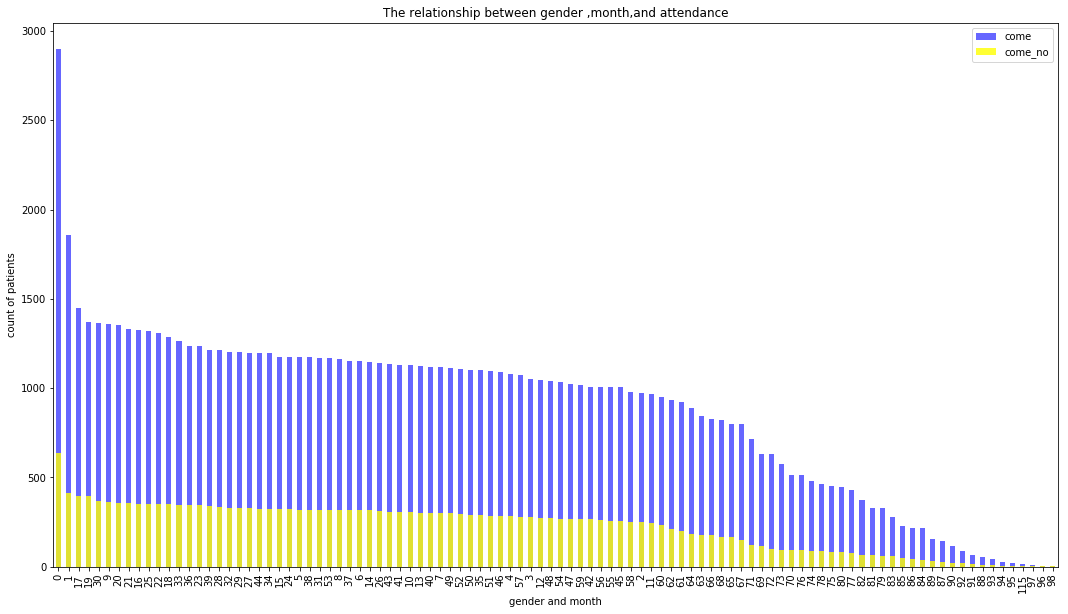

In [33]:
come_age.plot(kind='bar',alpha=0.6,color='blue',figsize=(18,10),label='come');
no_come_age.plot(kind='bar',alpha=0.8,color='yellow',figsize=(18,10),label = 'come_no');
plt.title('The relationship between gender ,month,and attendance')
plt.xlabel('gender and month');
plt.ylabel('count of patients');
plt.legend();

### Research Question 7:The relationship between the three variables of diabetes, high blood pressure and attendance

In [34]:
come_group_Diabetes_Hipertension=come.groupby(['Diabetes'])['Hipertension'].value_counts()
no_come_group_Diabetes_Hipertension=no_come.groupby(['Diabetes'])['Hipertension'].value_counts()

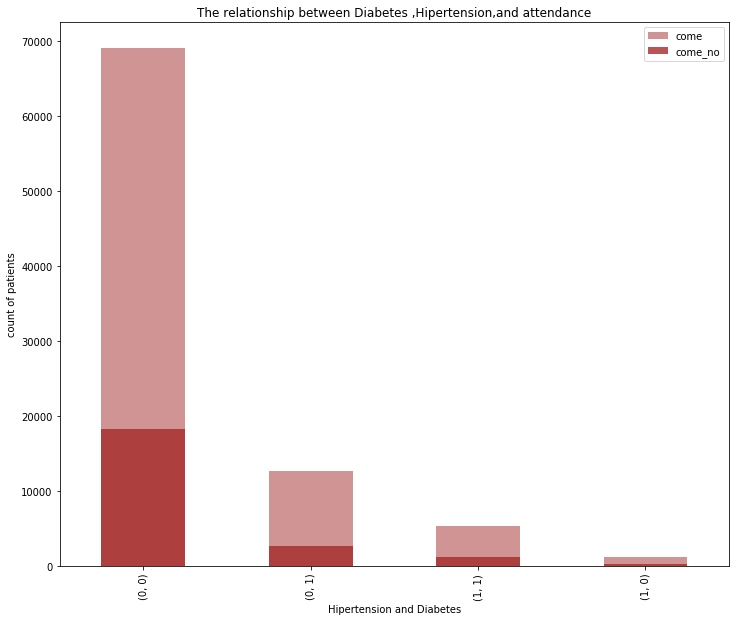

In [35]:
come_group_Diabetes_Hipertension.plot(kind='bar',alpha=0.5,color='brown',figsize=(12,10),label='come');
no_come_group_Diabetes_Hipertension.plot(kind='bar',alpha=0.8,color='brown',figsize=(12,10),label = 'come_no',);
plt.title('The relationship between Diabetes ,Hipertension,and attendance')
plt.xlabel('Hipertension and Diabetes');
plt.ylabel('count of patients');
plt.legend();

#### There is no relationship between blood pressure and diabetes in attendance, almost all ratios are very close

### Research Question 8:What hospitals have the highest attendance rates?

In [36]:
come_Neighbourhood=come['Neighbourhood'].value_counts()
no_come_Neighbourhood=no_come['Neighbourhood'].value_counts()

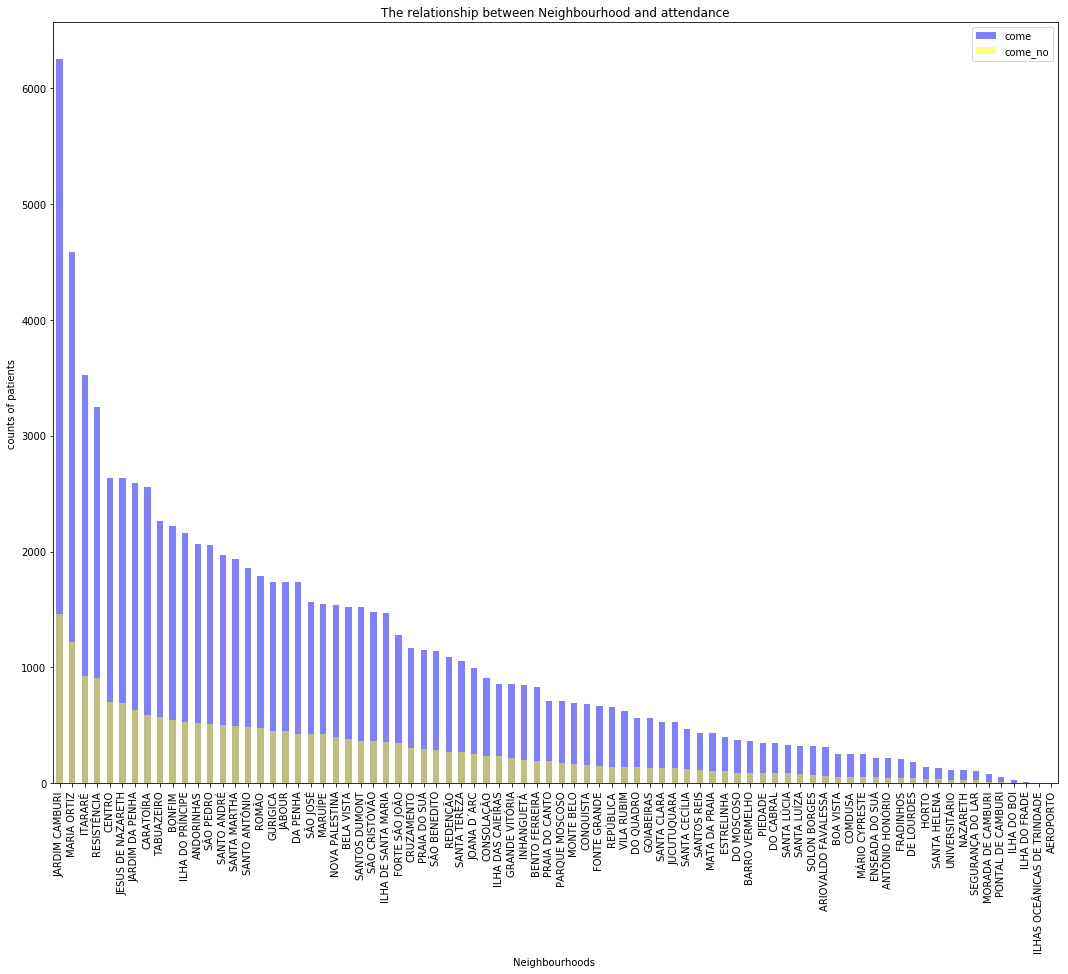

In [37]:
come_Neighbourhood.plot(kind='bar',alpha=0.5,color='blue',figsize=(18,14),label='come');
no_come_Neighbourhood.plot(kind='bar',alpha=0.5,color='yellow',figsize=(18,14),label = 'come_no');
plt.title('The relationship between Neighbourhood and attendance');
plt.xlabel('Neighbourhoods ');
plt.ylabel('counts of patients');
plt.legend();

<a id='conclusions'></a>
## Conclusions
<ul>
    <li>The location of the hospital affects attendance, the hospital "JARDLM CAMBURL" has the highest attendance rate</li>
    <li>Age affects attendance, as the lower the age, the higher the attendance rate ,vice versa</li>
    <li>Similarly, the day of the appointment affects attendance on Tuesday and Wednesday, the attendance rate is high</li>
    <li>There is a relationship between the month and attendance, in the month of 5 the attendance was very large and in the month of 4 it was very little</li>
    <li></li>
</ul> 

### Limitations

 


<ul>
    <li>I think the presence of a cell that expresses when the patient comes, what is the doctor examining. Is it a digestive system, an eye, or a bone? It will help more in determining the effects in the attendance and things like this</li>
    </ul>
   

In [38]:
from subprocess import call
call(['python', '-m', 'nbconvert', 'Investigate_a_Dataset.ipynb'])

0